Data is a raw fact, figure or information that processed, organized and interpreted can served as valuable resources for decision making.

- Source of Data
1. Primary source of data: these are first time data gotten directly by the research,  

Yes, there are several other features that you could consider collecting to enhance the predictive power of your depression prediction model:

### 1. **Sleep Patterns**
   - **Sleep Duration**: Total hours of sleep per night.
   - **Sleep Quality**: Self-reported quality of sleep (e.g., restful, disturbed).
   - **Sleep Disorders**: Presence of conditions like insomnia or sleep apnea.

### 2. **Diet and Nutrition**
   - **Diet Quality**: Frequency of healthy eating (e.g., fruits, vegetables).
   - **Caffeine/Alcohol Consumption**: Amount and frequency of consumption.
   - **Eating Habits**: Meal regularity, binge eating, etc.

### 3. **Physical Activity**
   - **Exercise Frequency**: How often they engage in physical activity.
   - **Type of Exercise**: Type of physical activity (e.g., cardio, strength training).

### 4. **Family History**
   - **Family History of Mental Illness**: Presence of depression or other mental health issues in the family.
   - **Genetic Factors**: If available, genetic predispositions to mental health issues.

### 5. **Social Support**
   - **Social Connections**: Number and quality of close relationships.
   - **Living Situation**: Whether the person lives alone, with family, or with friends.
   - **Marital/Relationship Status**: Single, married, divorced, etc.

### 6. **Environmental Factors**
   - **Work Environment**: Job stress levels, job satisfaction.
   - **Life Events**: Recent major life changes (e.g., death in the family, job loss).
   - **Neighborhood Safety**: Perception of safety in their living environment.

### 7. **Cognitive and Behavioral Factors**
   - **Coping Mechanisms**: How they deal with stress (e.g., substance use, meditation).
   - **Decision-Making Ability**: Self-reported difficulty in making decisions.
   - **Cognitive Load**: Number of ongoing responsibilities or stressors.

### 8. **Medical History**
   - **Chronic Illnesses**: Presence of chronic conditions (e.g., diabetes, hypertension).
   - **Medication Usage**: Types of medications currently being taken.
   - **Past Psychological Therapy**: Previous therapy or counseling experiences.

### 9. **Substance Use**
   - **Tobacco Use**: Frequency and amount of smoking.
   - **Recreational Drug Use**: Types and frequency of drug use.

### 10. **Personality Traits**
   - **Big Five Personality Traits**: Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism.
   - **Self-Esteem**: Self-reported levels of self-esteem.

Collecting these additional features could help you capture a more holistic picture of the factors contributing to depression, thereby improving the accuracy and generalizability of your model.


The columns you've listed can serve as useful features for a machine learning model aimed at predicting depression. Here's a breakdown of why these features could be valuable:

1. **Demographic Features**: 
   - **Age**, **Country**, **Education**, **Study**, **Employed**, **Disability**: These features provide a socio-demographic context which can help identify risk factors or protective factors associated with depression. For instance, unemployment or low education levels might correlate with higher depression risk.

2. **Health and Lifestyle**:
   - **Mental Health issue**, **Hour spend on fitness**, **Mouth dryness**, **Breath difficulties**, **Difficulties in initiate things**, **Trembling**: These features capture existing mental health conditions, physical symptoms, and lifestyle choices, all of which are critical indicators of depression.

3. **Psychosocial Factors**:
   - **Social media**, **Wind down**: These features can indicate social engagement, relaxation habits, and potential stressors, which might be linked to mental health outcomes.

4. **Emotional and Psychological States**:
   - **Positive feeling**, **Worrying situation**, **Feeling of nothing to look forward to**, **Downhearted**, **Enthusiastic about anything**, **Feel meaningless life**, **Scared**: These features directly measure emotional and cognitive states that are strongly associated with depression.

All these features seem relevant, but their effectiveness will depend on the quality and distribution of the data, as well as how well they correlate with the target variable (e.g., whether or not a person is depressed). It might also be useful to explore feature engineering or dimensionality reduction techniques to enhance model performance.

In [26]:
# import the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_score, StratifiedKFold, train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, r2_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

#import warnings
#warnings.filterwarnings("ignore")

In [2]:
# import the data into datafram
df = pd.read_csv("clean_data.csv")

In [3]:
df.duplicated().sum()

0

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Age                                    243 non-null    int64 
 1   country                                243 non-null    object
 2   Education                              243 non-null    object
 3   Study                                  243 non-null    int64 
 4   Employed                               243 non-null    object
 5   Disability                             243 non-null    object
 6   Mental Health issue                    243 non-null    object
 7   social media                           243 non-null    object
 8   Hour spend on fitness                  243 non-null    object
 9   wind down                              243 non-null    int64 
 10  Mouth dryness                          243 non-null    int64 
 11  positive feeling   

In [5]:
X = df.copy()
y = X.pop("depression status")

In [6]:
X.columns

Index(['Age', 'country', 'Education', 'Study', 'Employed', 'Disability',
       'Mental Health issue', 'social media', 'Hour spend on fitness',
       'wind down', 'Mouth dryness', 'positive feeling', 'breath difficulties',
       'difficulties in initiate things', 'trembling', 'worrying situation',
       'feeling of nothing to look forward to', 'down hearted',
       'enthusaistic about anything', 'feel meaningless life', 'scared'],
      dtype='object')

No, slightly, moderately, extremely

In [7]:
# Create train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
# cat_mask=X.select_dtypes("object").apply(pd.Series.nunique)==2 
# num_mask=X.select_dtypes(include=["int", "float"]).apply(pd.Series.nunique)>5
# ordinal_cols = cat_mask.index[cat_mask]
# nominal_column = cat_mask.index[~cat_mask]
# numerical_column = num_mask.index[num_mask]

In [9]:
ordinal_cols=["social media", "Hour spend on fitness", "wind down", "Mouth dryness","positive feeling"
              ,"breath difficulties", "difficulties in initiate things", "trembling", 
             "worrying situation", "feeling of nothing to look forward to", "down hearted",
             "enthusaistic about anything", "feel meaningless life", "scared"]

numerical_column = ["Study", "Age"]
nominal_column = ["country", "Education", "Employed", "Disability", "Mental Health issue"]

In [10]:
# Preprocessing for numerical data
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [11]:
# Preprocessing for ordinal data
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

In [12]:
# Preprocessing for nominal data
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [13]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_column),
        ('ord', ordinal_transformer, ordinal_cols),
        ('nom', nominal_transformer, nominal_column)
    ], remainder='passthrough'
)

In [27]:
# Starified k cross validation
Kfold = StratifiedKFold(n_splits=2)
K_fold= KFold(n_splits=5)

In [28]:
# Lets stack up our classifiers:

RANDOM_STATE = 42
classifiers = [LogisticRegression(max_iter=700, solver='sag', random_state=RANDOM_STATE),
               DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
               SVC(C=2, kernel='linear', random_state=RANDOM_STATE),
               RandomForestClassifier(
                   max_depth=7, min_samples_split=5, min_samples_leaf=5, random_state=RANDOM_STATE),
               AdaBoostClassifier(DecisionTreeClassifier(
                   max_depth=1, random_state=RANDOM_STATE), random_state=RANDOM_STATE),
               GradientBoostingClassifier(
                   learning_rate=0.005, n_estimators=30, random_state=RANDOM_STATE),
               #KNeighborsClassifier(),
               GaussianNB(var_smoothing=1e-2)
               ]

In [29]:
classifiers_names = ['Logistic Regression',
                     'Decision Tree Classifier',
                     'Support Vector Machine',
                     'Random Forest Classifier',
                     'AdaBoost Classifier',
                     'Gradient Boosting Classifier',
                   #  'K Neighbors Classifier',
                     'Gaussian Naive Bayes']

pipelines = [Pipeline([('transformer', preprocessor), (classifier_name, classifier)])
             for classifier_name, classifier in zip(classifiers_names, classifiers)]


In [30]:
# Cross Validation.
def cv_fit_models():
    train_acc_results = []
    cv_scores = {classifier_name: [] for classifier_name in classifiers_names}
    for classifier_name, pipeline in zip(classifiers_names, pipelines):
        cv_score = cross_validate(pipeline,
                                  X,
                                  y,
                                  scoring=scoring,
                                  cv=K_fold,
                                  return_train_score=True,
                                  return_estimator=True)

        train_accuracy = cv_score['train_acc'].mean() * 100
        
        train_acc_results.append(train_accuracy)
        cv_scores[classifier_name].append(cv_score)

    return np.array(train_acc_results), cv_scores

In [ ]:
scoring = {'acc': 'accuracy'}

results, folds_scores = cv_fit_models()

In [32]:
folds_scores

{'Logistic Regression': [{'fit_time': array([0.49075818, 0.26217055, 0.33743596, 0.46216106, 0.34403491]),
   'score_time': array([0.01674056, 0.0221045 , 0.02544546, 0.01663733, 0.01562214]),
   'estimator': [Pipeline(steps=[('transformer',
                     ColumnTransformer(remainder='passthrough',
                                       transformers=[('num',
                                                      Pipeline(steps=[('imputer',
                                                                       SimpleImputer()),
                                                                      ('scaler',
                                                                       StandardScaler())]),
                                                      ['Study', 'Age']),
                                                     ('ord',
                                                      Pipeline(steps=[('imputer',
                                                                       Si

In [33]:
# Pick the best fold for each model according to the highest test accuracy:
def pick_best_estimator():
    best_estimators = {classifier_name: [] for classifier_name in classifiers_names}
    for key, model in folds_scores.items():
        best_acc_idx = np.argmax(model[0]['test_acc'])
        best_model = model[0]['estimator'][best_acc_idx]
        best_estimators[key].append(best_model)
    return best_estimators

In [34]:
# Pick the best fold for each model according to the highest test accuracy:

best_estimators = {classifier_name: [] for classifier_name in classifiers_names}
for key, model in folds_scores.items():
    best_acc_idx = np.argmax(model[0]['test_acc'])
    print(best_acc_idx)
    #best_model = model[0]['estimator'][best_acc_idx]
    #best_estimators[key].append(best_model)


2
2
3
2
2
4
3


In [35]:
# Pick the best fold for each model according to the highest test accuracy:

best_estimators = {classifier_name: [] for classifier_name in classifiers_names}
for key, model in folds_scores.items():
    print(model)
   # print(best_acc_idx)
    #best_model = model[0]['estimator'][best_acc_idx]
    #best_estimators[key].append(best_model)


[{'fit_time': array([0.49075818, 0.26217055, 0.33743596, 0.46216106, 0.34403491]), 'score_time': array([0.01674056, 0.0221045 , 0.02544546, 0.01663733, 0.01562214]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.05344415, 0.05591631, 0.07018089, 0.03124094, 0.05632281]), 'score_time': array([0.01570344, 0.03302741, 0.02885532, 0.01562071, 0.02006698]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.06863999, 0.05526924, 0.06475353, 0.06248736, 0.04683399]), 'score_time': array([0.03256392, 0.01588464, 0.01558304, 0.0168066 , 0.03243566]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.35405111, 0.27807879, 0.25715661, 0.26675129, 0.2879622 ]), 'score_time': array([0.04202557, 0.01567364, 0.03269434, 0.03128362, 0.01675653]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.17271805, 0.20711255, 0.20240045, 0.1789825 , 0.17901111]), 'score_time': array([0.03774762, 0.03469753, 0.02382684, 0.03596473, 0.03689528]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.34767866, 0.3008368 , 0.34793139, 0.44269466, 0.34725285]), 'score_time': array([0.01106429, 0.01070929, 0.01322007, 0.01300192, 0.02373862]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

[{'fit_time': array([0.02398562, 0.03603697, 0.03485894, 0.02399063, 0.03705549]), 'score_time': array([0.02393031, 0.01209593, 0.01308274, 0.02414441, 0.01096439]), 'estimator': [Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study', 'Age']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                              

In [36]:
best_acc_idx

3

In [37]:
best_estimators = pick_best_estimator()

In [38]:
best_estimators

{'Logistic Regression': [Pipeline(steps=[('transformer',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('num',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer()),
                                                                    ('scaler',
                                                                     StandardScaler())]),
                                                    ['Study', 'Age']),
                                                   ('ord',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='most_frequent')),
                                                                    ('ordinal',
                                                                     OrdinalEncoder()

In [39]:
# Now we finally can get the accuracy scores of each best fold 
# and at the same time get their precision & recall scores:

def gather_metrics_scores():
    test_accs, precisions, recalls = [], [], []
    for estimator_val in best_estimators.values():
        estimator = estimator_val[0]
        y_pred = estimator.predict(X_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        score = estimator.score(X_test, y_test)

        test_accs.append(score)
        precisions.append(precision)
        recalls.append(recall)
        
    scores = {'test_acc': np.array(test_accs),
              'precision': np.array(precisions),
              'recall': np.array(recalls)}
    
    return scores

In [ ]:
scores = gather_metrics_scores()

In [41]:
scores

{'test_acc': array([0.85245902, 0.67213115, 0.90163934, 0.90163934, 0.67213115,
        0.80327869, 0.85245902]),
 'precision': array([0.86423781, 0.48321624, 0.90671787, 0.90913349, 0.48321624,
        0.74612802, 0.86487119]),
 'recall': array([0.85245902, 0.67213115, 0.90163934, 0.90163934, 0.67213115,
        0.80327869, 0.85245902])}

In [42]:
# Plot metrics
def plot_train_test_accuracy(df):
    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))
    sns.barplot(data=df, x='train_accuracy',
                y='Model', orient='h', ax=ax[0],
               order=df.sort_values('train_accuracy',ascending = False).Model)
    ax[0].set_xlim([0, 100])
    sns.barplot(data=df, x='test_accuracy',
                y='Model', orient='h', ax=ax[1],
               order=df.sort_values('test_accuracy',ascending = False).Model)
    ax[1].set_xlim([0, 100])

In [43]:
results_df = pd.DataFrame({'Model': classifiers_names,
                           'train_accuracy': results,
                           'test_accuracy': scores['test_acc'] * 100,
                           'test_precision': scores['precision'] * 100,
                           'test_recall': scores['recall'] * 100})

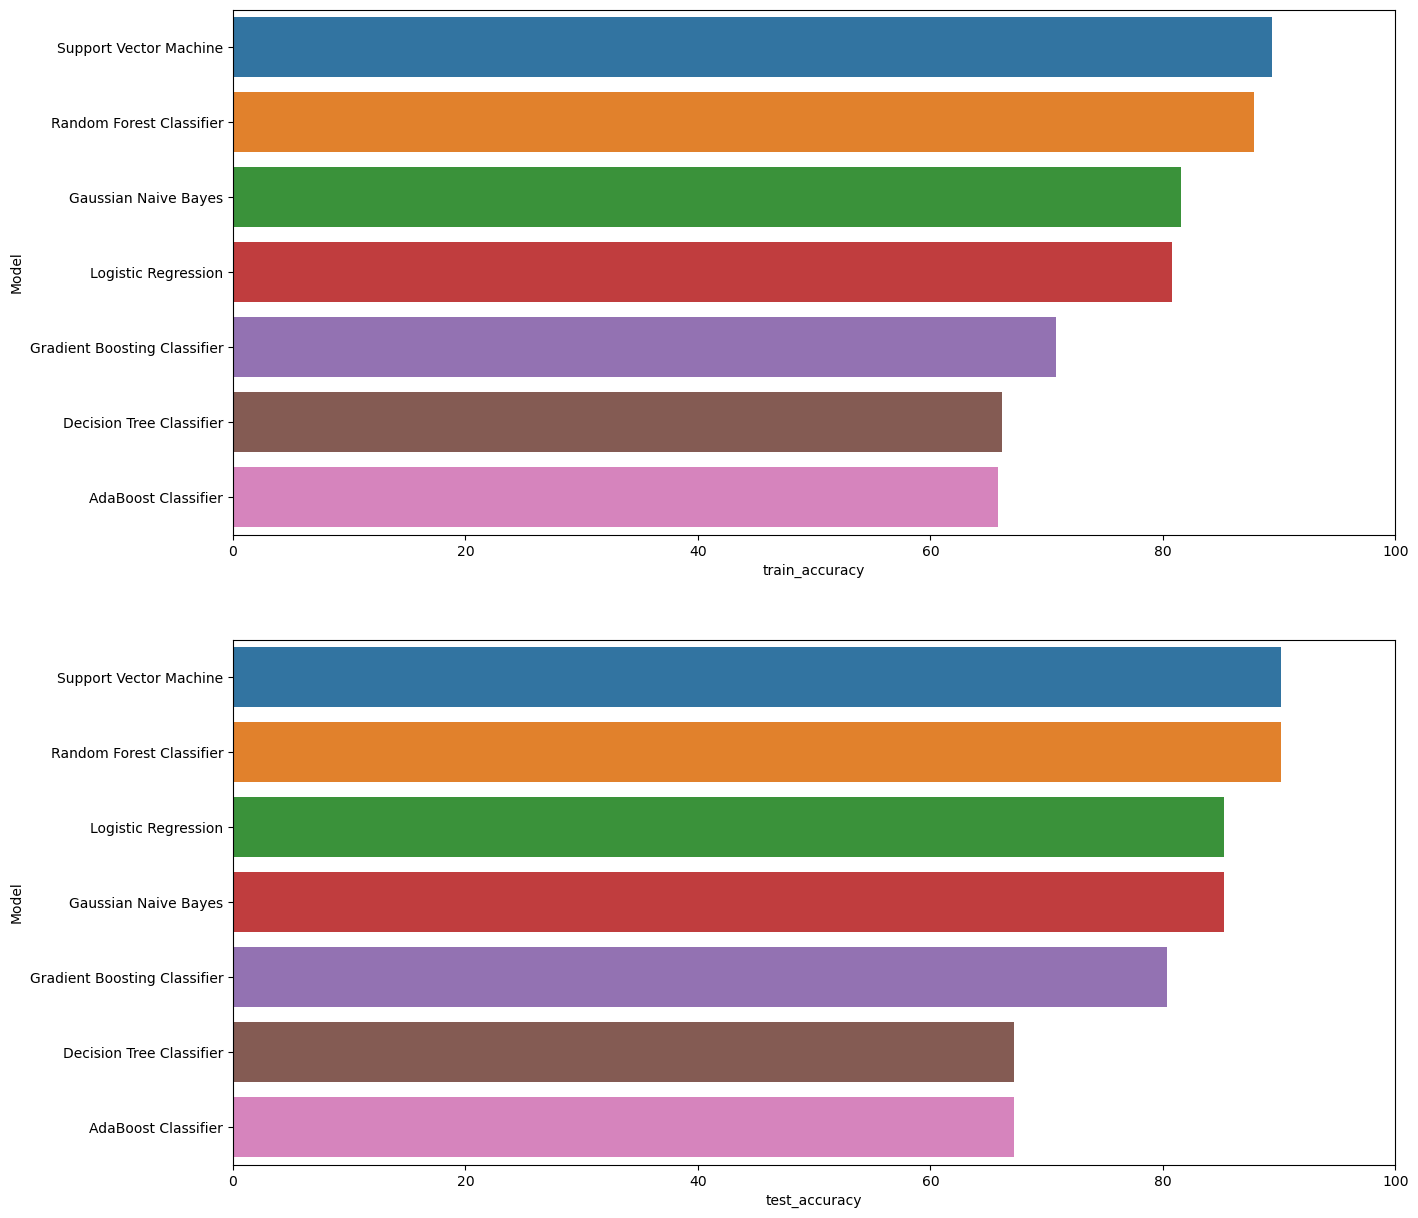

In [44]:
plot_train_test_accuracy(results_df)

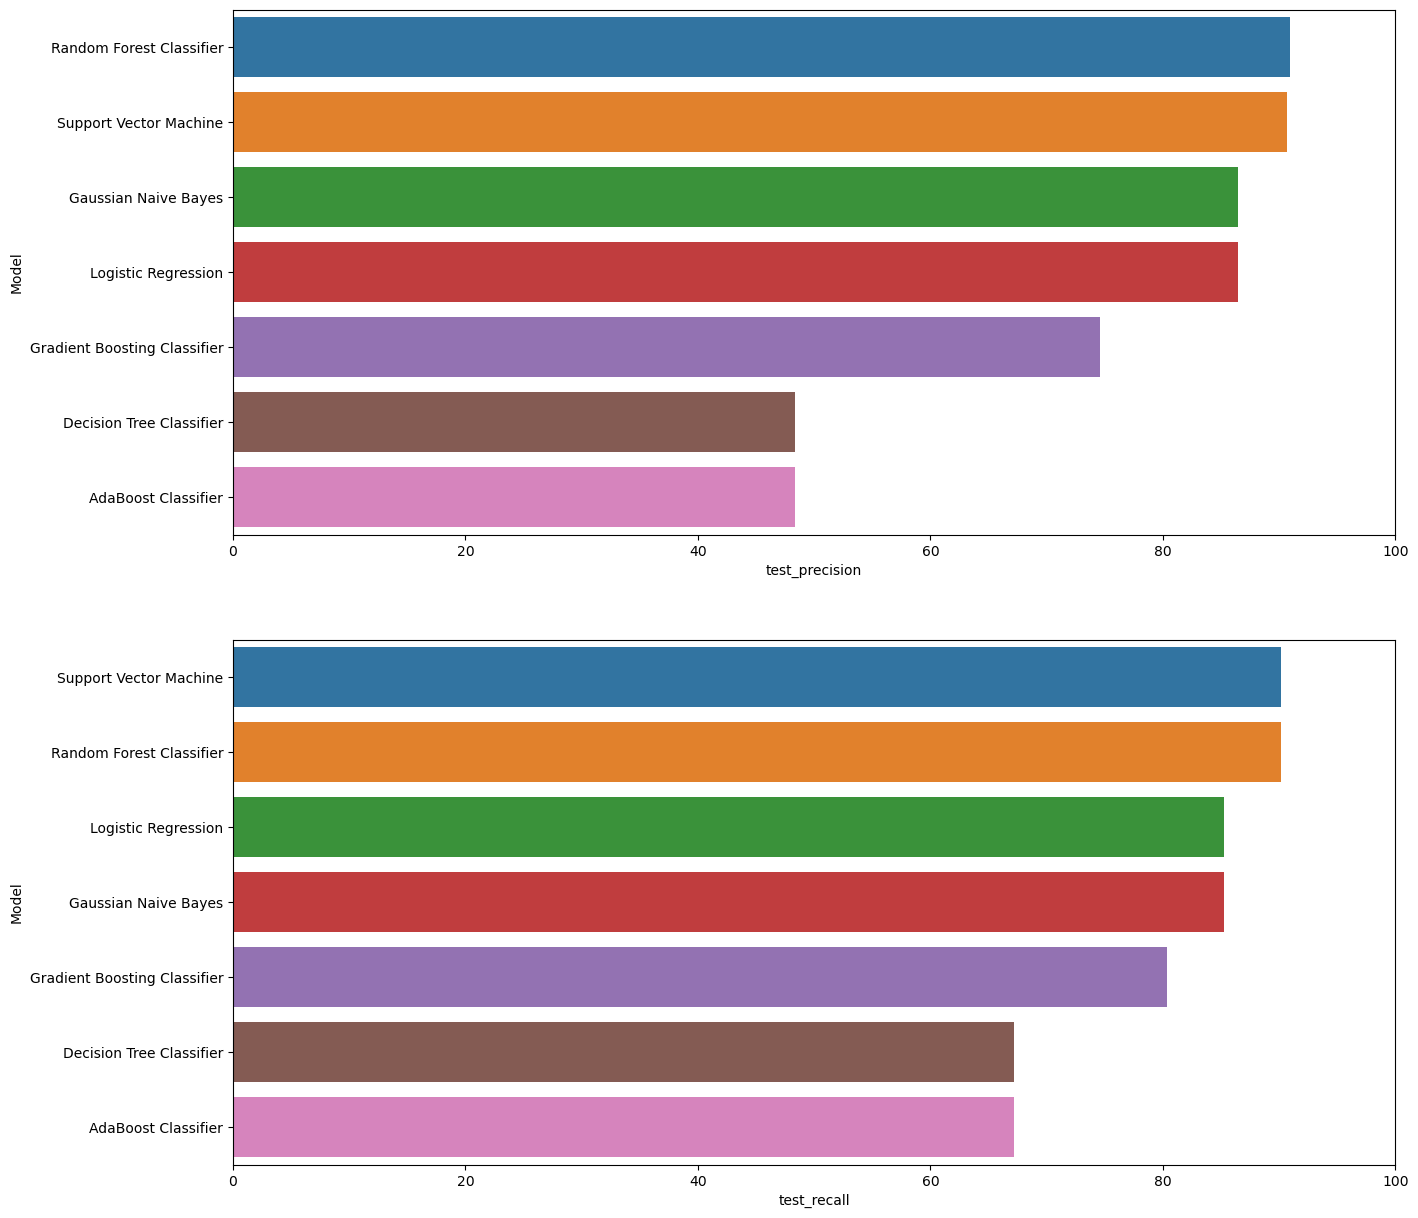

In [45]:
def plot_precision_recall(df):
    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))
    sns.barplot(data=df, x='test_precision',
                y='Model', orient='h', ax=ax[0],
               order=df.sort_values('test_precision',ascending = False).Model)
    ax[0].set_xlim([0, 100])
    sns.barplot(data=df, x='test_recall',
                y='Model', orient='h', ax=ax[1],
               order=df.sort_values('test_recall',ascending = False).Model)
    ax[1].set_xlim([0, 100])
plot_precision_recall(results_df)

In [ ]:
# # from sklearn.linear_model import LogisticRegression
# # from sklearn.svm import SVC
# # from sklearn.tree import DecisionTreeClassifier
# # from sklearn.ensemble import RandomForestClassifier
# # from sklearn.neighbors import KNeighborsClassifier
# # from sklearn.naive_bayes import GaussianNB
# # from sklearn.naive_bayes import MultinomialNB
# # from xgboost import XGBClassifier
# # from lightgbm import LGBMClassifier
# # from sklearn.neural_network import MLPClassifier
# # from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# # from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# # from sklearn.ensemble import VotingClassifier





# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import Lasso
# from sklearn.linear_model import Rifrom sklearn.ensemble 
# import VotingRegressorfrom sklearn.linear_model 
# import BayesianRidgefrom sklearn.linear_model 
# import BayesianRidgedge
# from sklearn.svm import SVR
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from sklearn.neural_network import MLPRegressor
# from lightgbm import LGBMRegressor
# from sklearn.linear_model import ElasticNet
# from sklearn.linear_model import HuberRegressor
# from sklearn.linear_model import PassiveAggressiveRegressor
# from sklearn.linear_model import BayesianRidge
# from sklearn.ensemble import VotingRegressor

